# 05. Meme Kanseri Tanı Sınıflandırması

**Kategori:** Sınıflandırma  
**Gerçek veri seti:** Wisconsin Diagnostic Breast Cancer  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)  
**Amaç:** Hücre çekirdeği ölçümlerinden iyi/kötü huylu sınıfını eğitim amaçlı tahmin etmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veri ve EDA

In [2]:
from sklearn.datasets import load_breast_cancer
d = load_breast_cancer(as_frame=True)
df = d.frame.copy()
df["diagnosis"] = df.target.map(dict(enumerate(d.target_names)))
display(df.head())
print("Boyut:", df.shape, "| Eksik:", int(df.isna().sum().sum()))
display(df.diagnosis.value_counts().to_frame("adet"))

Boyut: (569, 32) | Eksik: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


,adet
diagnosis,
benign,357
malignant,212


,|hedef korelasyonu|
target,1.000
worst concave points,0.794
worst perimeter,0.783
mean concave points,0.777
worst radius,0.776
mean perimeter,0.743
worst area,0.734
mean radius,0.730


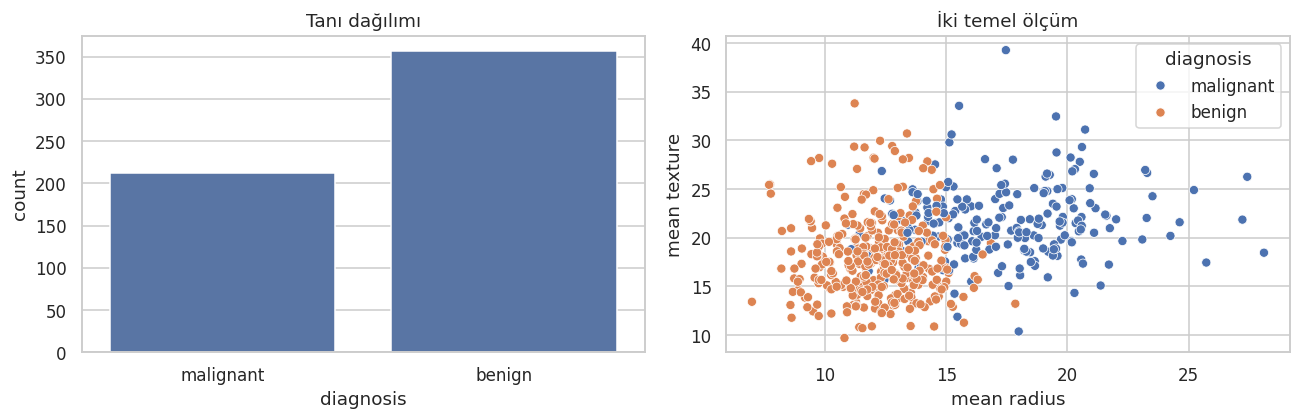

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="diagnosis", ax=axes[0])
axes[0].set(title="Tanı dağılımı")
sns.scatterplot(data=df, x="mean radius", y="mean texture", hue="diagnosis", ax=axes[1])
axes[1].set(title="İki temel ölçüm")
plt.tight_layout(); plt.show()
top_corr = df.drop(columns="diagnosis").corr().target.abs().sort_values(ascending=False).head(8)
display(top_corr.to_frame("|hedef korelasyonu|").round(3))

## 2. Model karşılaştırması

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = d.data, d.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE
)
candidates = {
    "Lojistik Regresyon": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000,
                                                                              class_weight="balanced")),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                              random_state=RANDOM_STATE, n_jobs=-1),
}
fitted = {name: model.fit(X_train, y_train) for name, model in candidates.items()}
rows = {name: {"accuracy": accuracy_score(y_test, model.predict(X_test)),
               "f1": f1_score(y_test, model.predict(X_test)),
               "roc_auc": roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}
        for name, model in fitted.items()}
scores = pd.DataFrame(rows).T.sort_values("roc_auc", ascending=False)
display(scores.round(3))
best_name = scores.index[0]; best_model = fitted[best_name]; pred = best_model.predict(X_test)
print(classification_report(y_test, pred, target_names=d.target_names))

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



,accuracy,f1,roc_auc
Lojistik Regresyon,0.956,0.965,0.995
Random Forest,0.947,0.958,0.994


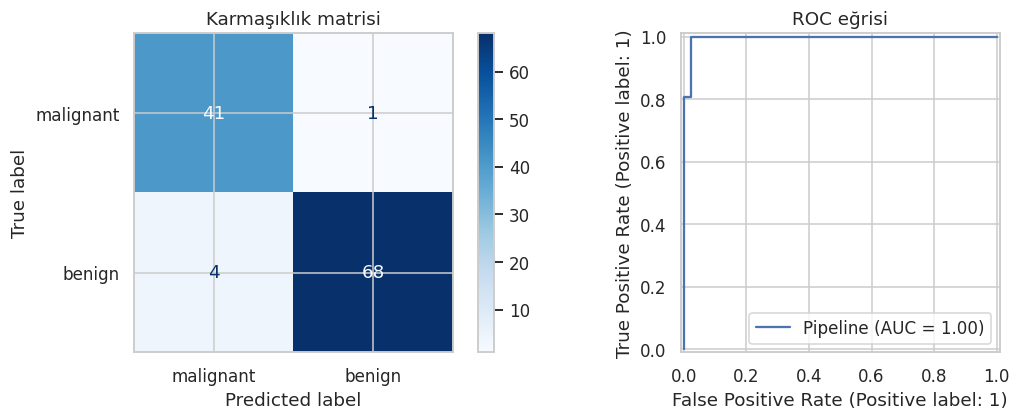

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=d.target_names,
                                        cmap="Blues", ax=axes[0])
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[0].set_title("Karmaşıklık matrisi"); axes[1].set_title("ROC eğrisi")
plt.tight_layout(); plt.show()
joblib.dump({"best_name": best_name, "best_model": best_model, "all_models": fitted,
             "feature_names": d.feature_names, "target_names": d.target_names.tolist(),
             "metrics": scores.to_dict()}, MODEL_DIR / "05_meme_kanseri.joblib")
json.dump({"best_model": best_name, **scores.loc[best_name].to_dict()},
          open(RESULT_DIR / "05_meme_kanseri.json", "w"), indent=2)

## Sonuç ve etik sınır

ROC-AUC, farklı karar eşiklerinde ayırma gücünü gösterdiği için model seçimi bu metrikle yapıldı.
Bu çalışma yalnızca eğitim amaçlıdır; klinik tanı, hekim kararı veya gerçek hasta yönetimi için
kullanılamaz.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **tümör sınıflandırmasında doğruluk** biçimindedir.
Bu notebookta **dengesizliği dikkate alan ağırlıklar, ROC-AUC, confusion matrix ve açık klinik kullanım sınırı** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).